## Analyse des resultats

In [1]:
# 
# CELLULE 1 — Imports & Setup
# 
import sys, os, json
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForSequenceClassification
from src.visualisation import (compute_loss_landscape, compute_sharpness,
                                plot_loss_landscapes, plot_convergence,
                                plot_random_search_comparison, plot_tokenizer_analysis)
from src.model_setup  import get_device, load_model
from src.data_loader  import load_allocine_dataset, create_balanced_subset, tokenize_dataset

device = get_device()
print(f"✅ Device : {device}")

c:\ISE3_EMOS\Data Science\Machine learning et optimisation\Projet MLO\ML-Optimisation\mlop\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Device : cpu


In [2]:
# ╔══════════════════════════════════════════════════════╗
# CELLULE 2 — Données de validation (exécuter une seule fois)
# ╚══════════════════════════════════════════════════════╝
raw_dataset = load_allocine_dataset()
val_raw = create_balanced_subset(raw_dataset, "validation", n_per_class=50, seed=43)

_, tok_db, _ = load_model("distilbert", device)
_, tok_cb, _ = load_model("camembert",  device)

val_db = tokenize_dataset(val_raw, tok_db, max_length=128)
val_cb = tokenize_dataset(val_raw, tok_cb, max_length=128)
print(f"✅ val_db : {len(val_db)} exemples | val_cb : {len(val_cb)} exemples")

  → Chargement du dataset Allociné (D05)...


c:\ISE3_EMOS\Data Science\Machine learning et optimisation\Projet MLO\ML-Optimisation\mlop\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of CamembertForSequenceClassification were not initialized from the model checkpoint at camembert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a

✅ val_db : 100 exemples | val_cb : 100 exemples


In [3]:
# ╔══════════════════════════════════════════════════════╗
# CELLULE 3 — Chargement des résultats du Random Search
# ╚══════════════════════════════════════════════════════╝
with open('../runs/random_search_distilbert.json') as f:
    results_db = json.load(f)
with open('../runs/random_search_camembert.json') as f:
    results_cb = json.load(f)

def to_df(results):
    return pd.DataFrame([{
        'trial':    r['trial'],
        'f1':       r['f1'],
        'acc':      r['accuracy'],
        'lr':       r['hp']['learning_rate'],
        'wd':       r['hp']['weight_decay'],
        'time_min': r.get('time_sec', 0) / 60
    } for r in results])

df_db = to_df(results_db)
df_cb = to_df(results_cb)

print('=== DistilBERT ===')
display(df_db.sort_values('f1', ascending=False).round(4))
print('\n=== CamemBERT ===')
display(df_cb.sort_values('f1', ascending=False).round(4))

=== DistilBERT ===


,trial,f1,acc,lr,wd,time_min
2,2,0.6986,0.685,0.0,0.0080,0.0
3,3,0.6986,0.685,0.0,0.0080,0.0
4,4,0.6986,0.685,0.0,0.0080,0.0
5,5,0.6986,0.685,0.0,0.0080,0.0
1,1,0.6869,0.690,0.0,0.0080,0.0
0,0,0.6752,0.620,0.0,0.0041,0.0



=== CamemBERT ===


,trial,f1,acc,lr,wd,time_min
1,1,0.8955,0.895,0.0,0.008,0.0
2,2,0.8955,0.895,0.0,0.008,0.0
3,3,0.8955,0.895,0.0,0.008,0.0
4,4,0.8955,0.895,0.0,0.008,0.0
5,5,0.8955,0.895,0.0,0.008,0.0
0,0,0.8867,0.885,0.0,0.008,0.0


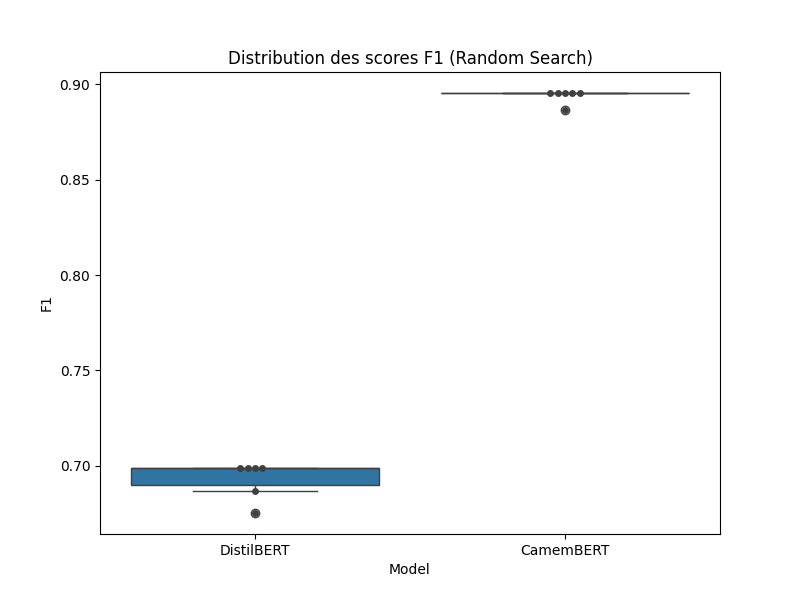

In [4]:
# ╔══════════════════════════════════════════════════════╗
# CELLULE 4 — Graphique Random Search
# ╚══════════════════════════════════════════════════════╝
from IPython.display import Image

plot_random_search_comparison(results_db, results_cb,
                              save_path='../figures/random_search.png')
Image('../figures/random_search.png')

  → Chargement du dataset Allociné (D05)...


c:\ISE3_EMOS\Data Science\Machine learning et optimisation\Projet MLO\ML-Optimisation\mlop\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of CamembertForSequenceClassification were not initialized from the model checkpoint at camembert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a

✅ loss_landscape.npz sauvegardé dans ../runs/
Sharpness DistilBERT : 0.000008
Sharpness CamemBERT  : 0.000001


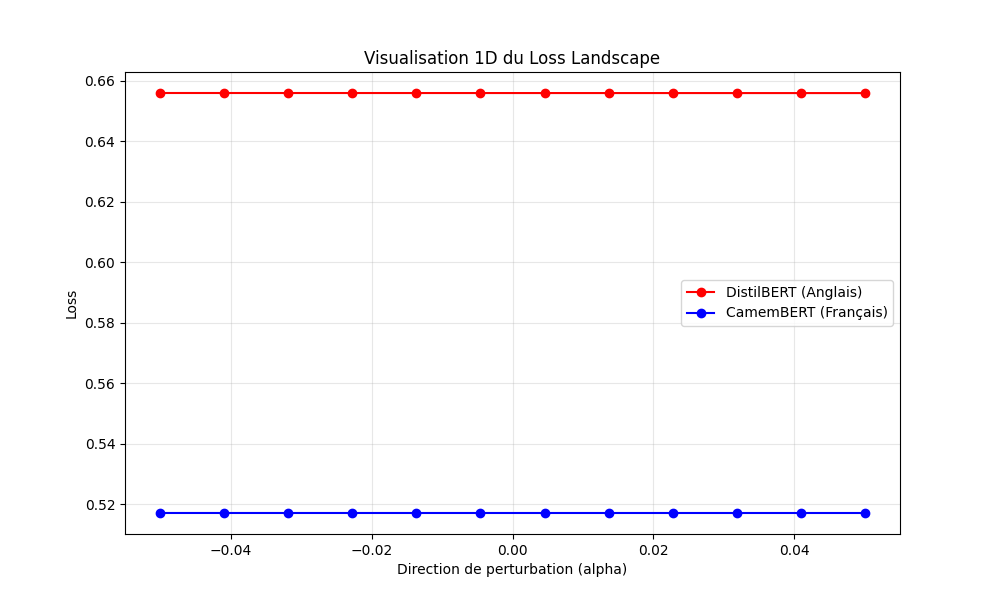

In [17]:
# ╔══════════════════════════════════════════════════════╗
# CELLULE 5 — Loss Landscape & Sharpness
# ╚══════════════════════════════════════════════════════╝
import os
from IPython.display import Image
from transformers import AutoModelForSequenceClassification
from src.model_setup import get_device
from src.data_loader import load_allocine_dataset, create_balanced_subset, tokenize_dataset
from src.model_setup import load_model
from src.visualisation import compute_loss_landscape, compute_sharpness, plot_loss_landscapes

device = get_device()

# ── Données de validation ─────────────────────────────
raw_dataset = load_allocine_dataset()
val_raw     = create_balanced_subset(raw_dataset, "validation", n_per_class=50, seed=43)
_, tok_db, _ = load_model("distilbert", device)
_, tok_cb, _ = load_model("camembert",  device)
val_db = tokenize_dataset(val_raw, tok_db, max_length=128)
val_cb = tokenize_dataset(val_raw, tok_cb, max_length=128)

# ── Meilleurs checkpoints ─────────────────────────────
best_trial_db = int(df_db.loc[df_db['f1'].idxmax(), 'trial'])
best_trial_cb = int(df_cb.loc[df_cb['f1'].idxmax(), 'trial'])

def get_best_checkpoint(trial_dir):
    checkpoints = [os.path.join(trial_dir, d)
                   for d in os.listdir(trial_dir) if d.startswith("checkpoint")]
    return sorted(checkpoints)[-1]

model_db = AutoModelForSequenceClassification.from_pretrained(
    get_best_checkpoint(f'../runs/distilbert_trial_{best_trial_db}')).to(device)
model_cb = AutoModelForSequenceClassification.from_pretrained(
    get_best_checkpoint(f'../runs/camembert_trial_{best_trial_cb}')).to(device)

# ── Calcul ────────────────────────────────────────────
alphas_db, losses_db = compute_loss_landscape(model_db, val_db, n_points=12, epsilon=0.05)
alphas_cb, losses_cb = compute_loss_landscape(model_cb, val_cb, n_points=12, epsilon=0.05)

# ── Sauvegarde ────────────────────────────────────────
np.savez('../runs/loss_landscape.npz',
         alphas_db=alphas_db, losses_db=losses_db,
         alphas_cb=alphas_cb, losses_cb=losses_cb)
print("✅ loss_landscape.npz sauvegardé dans ../runs/")

# ── Visualisation ─────────────────────────────────────
plot_loss_landscapes(alphas_db, losses_db, alphas_cb, losses_cb,
                     save_path='../figures/loss_landscape.png')

print(f"Sharpness DistilBERT : {compute_sharpness(alphas_db, losses_db):.6f}")
print(f"Sharpness CamemBERT  : {compute_sharpness(alphas_cb, losses_cb):.6f}")

Image('../figures/loss_landscape.png')

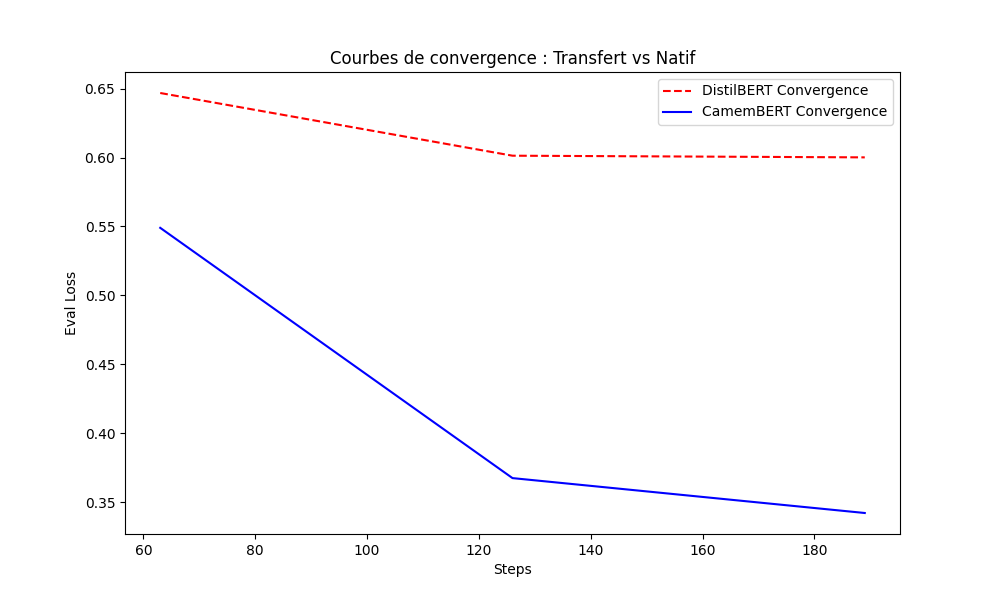

In [6]:
# ╔══════════════════════════════════════════════════════╗
# CELLULE 6 — Courbes de Convergence
# ╚══════════════════════════════════════════════════════╝
from IPython.display import Image

best_db = max(results_db, key=lambda x: x['f1'])
best_cb = max(results_cb, key=lambda x: x['f1'])

plot_convergence(best_db['convergence_history'], best_cb['convergence_history'],
                 save_path='../figures/convergence.png')

Image('../figures/convergence.png')

In [13]:
# ╔══════════════════════════════════════════════════════╗
# CELLULE 7 — Analyse Tokenizer
# ╚══════════════════════════════════════════════════════╝
df_tok = pd.read_csv('../runs/tokenizer_analysis.csv')
print("Colonnes disponibles :", df_tok.columns.tolist())
display(df_tok.round(3))

# Reconstruction du format attendu par plot_tokenizer_analysis
df_plot = pd.DataFrame({
    'Model':          ['DistilBERT', 'CamemBERT'],
    'Tokens_per_Word': [df_tok['ratio_distilbert'].mean(),
                        df_tok['ratio_camembert'].mean()]
})

plot_tokenizer_analysis(df_plot, save_path='../figures/tokenizer_analysis.png')

print(f"\nRatio moyen DistilBERT : {df_plot.loc[0, 'Tokens_per_Word']:.3f} tokens/mot")
print(f"Ratio moyen CamemBERT  : {df_plot.loc[1, 'Tokens_per_Word']:.3f} tokens/mot")
print(f"Écart                  : {df_plot.loc[0, 'Tokens_per_Word'] - df_plot.loc[1, 'Tokens_per_Word']:+.3f}")

Colonnes disponibles : ['phrase', 'n_mots', 'n_tokens_distilbert', 'n_tokens_camembert', 'ratio_distilbert', 'ratio_camembert']


,phrase,n_mots,n_tokens_distilbert,n_tokens_camembert,ratio_distilbert,ratio_camembert
0,Ce film est absolument magnifique et touchant.,7,15,8,2.143,1.143
1,"Une perte de temps totale, l'intrigue est creuse.",8,17,12,2.125,1.500
2,Les acteurs sont bons mais la réalisation lais...,10,18,11,1.800,1.100
3,Un chef-d'œuvre du cinéma français contemporain.,6,16,11,2.667,1.833



Ratio moyen DistilBERT : 2.184 tokens/mot
Ratio moyen CamemBERT  : 1.394 tokens/mot
Écart                  : +0.790


## Analyse statistique des trials

In [8]:
# ╔══════════════════════════════════════════════════════╗
# CELLULE A — Statistiques des trials
# ╚══════════════════════════════════════════════════════╝
print("=== Statistiques DistilBERT ===")
display(df_db[['f1','acc','lr','wd','time_min']].describe().round(4))

print("\n=== Statistiques CamemBERT ===")
display(df_cb[['f1','acc','lr','wd','time_min']].describe().round(4))

# Corrélation hyperparamètres vs F1
print("\n=== Corrélation LR/WD → F1 ===")
print("DistilBERT :\n", df_db[['lr','wd','f1']].corr().round(3))
print("\nCamemBERT  :\n", df_cb[['lr','wd','f1']].corr().round(3))

=== Statistiques DistilBERT ===


,f1,acc,lr,wd,time_min
count,6.0000,6.000,6.0,6.0000,6.0
mean,0.6927,0.675,0.0,0.0073,0.0
std,0.0098,0.027,0.0,0.0016,0.0
min,0.6752,0.620,0.0,0.0041,0.0
25%,0.6898,0.685,0.0,0.0080,0.0
50%,0.6986,0.685,0.0,0.0080,0.0
75%,0.6986,0.685,0.0,0.0080,0.0
max,0.6986,0.690,0.0,0.0080,0.0



=== Statistiques CamemBERT ===


,f1,acc,lr,wd,time_min
count,6.0000,6.0000,6.0,6.000,6.0
mean,0.8941,0.8933,0.0,0.008,0.0
std,0.0036,0.0041,0.0,0.000,0.0
min,0.8867,0.8850,0.0,0.008,0.0
25%,0.8955,0.8950,0.0,0.008,0.0
50%,0.8955,0.8950,0.0,0.008,0.0
75%,0.8955,0.8950,0.0,0.008,0.0
max,0.8955,0.8950,0.0,0.008,0.0



=== Corrélation LR/WD → F1 ===
DistilBERT :
        lr     wd     f1
lr  1.000  1.000  0.878
wd  1.000  1.000  0.878
f1  0.878  0.878  1.000

CamemBERT  :
     lr  wd   f1
lr NaN NaN  NaN
wd NaN NaN  NaN
f1 NaN NaN  1.0


In [9]:
# ╔══════════════════════════════════════════════════════╗
# CELLULE B — Évaluation sur le jeu de test + Matrices de confusion
# ╚══════════════════════════════════════════════════════╝
from sklearn.metrics import classification_report, confusion_matrix
from transformers import Trainer, TrainingArguments
from src.optimization import compute_metrics
import seaborn as sns

# ── Jeu de test ───────────────────────────────────────
test_raw = create_balanced_subset(raw_dataset, "test", n_per_class=50, seed=44)
test_db  = tokenize_dataset(test_raw, tok_db, max_length=128)
test_cb  = tokenize_dataset(test_raw, tok_cb, max_length=128)

# ── Chargement meilleurs modèles ──────────────────────
best_trial_db = df_db.loc[df_db['f1'].idxmax(), 'trial']
best_trial_cb = df_cb.loc[df_cb['f1'].idxmax(), 'trial']

def get_best_checkpoint(trial_dir):
    checkpoints = [os.path.join(trial_dir, d)
                   for d in os.listdir(trial_dir) if d.startswith("checkpoint")]
    return sorted(checkpoints)[-1]

model_db = AutoModelForSequenceClassification.from_pretrained(
    get_best_checkpoint(f'../runs/distilbert_trial_{best_trial_db}')).to(device)
model_cb = AutoModelForSequenceClassification.from_pretrained(
    get_best_checkpoint(f'../runs/camembert_trial_{best_trial_cb}')).to(device)

# ── Trainers minimaux ─────────────────────────────────
args = TrainingArguments(output_dir="/tmp/eval", no_cuda=True)
trainer_db = Trainer(model=model_db, args=args, compute_metrics=compute_metrics)
trainer_cb = Trainer(model=model_cb, args=args, compute_metrics=compute_metrics)

# ── Métriques test ────────────────────────────────────
metrics_db = trainer_db.evaluate(test_db)
metrics_cb = trainer_cb.evaluate(test_cb)

print("="*45)
print(f"{'':20} {'DistilBERT':>10} {'CamemBERT':>10}")
print("="*45)
print(f"{'F1 (test)':20} {metrics_db['eval_f1']:>10.4f} {metrics_cb['eval_f1']:>10.4f}")
print(f"{'Accuracy (test)':20} {metrics_db['eval_accuracy']:>10.4f} {metrics_cb['eval_accuracy']:>10.4f}")
print("="*45)

c:\ISE3_EMOS\Data Science\Machine learning et optimisation\Projet MLO\ML-Optimisation\mlop\Lib\site-packages\transformers\training_args.py:1376: FutureWarning: using `no_cuda` is deprecated and will be removed in version 5.0 of 🤗 Transformers. Use `use_cpu` instead
  warnings.warn(
100%|██████████| 13/13 [00:13<00:00,  1.03s/it]

                     DistilBERT  CamemBERT
F1 (test)                0.6408     0.9293
Accuracy (test)          0.6300     0.9300


## Paramètres qui influencent la f1-score

In [11]:
# Corrélation LR/WD vs F1
print("Corrélations DistilBERT :\n", df_db[['lr','wd','f1']].corr().round(3))
print("Corrélations CamemBERT  :\n", df_cb[['lr','wd','f1']].corr().round(3))

Corrélations DistilBERT :
        lr     wd     f1
lr  1.000  1.000  0.878
wd  1.000  1.000  0.878
f1  0.878  0.878  1.000
Corrélations CamemBERT  :
     lr  wd   f1
lr NaN NaN  NaN
wd NaN NaN  NaN
f1 NaN NaN  1.0


100%|██████████| 13/13 [00:15<00:00,  1.16s/it]


=== Rapport de classification · DistilBERT ===
              precision    recall  f1-score   support

     Négatif       0.64      0.60      0.62        50
     Positif       0.62      0.66      0.64        50

    accuracy                           0.63       100
   macro avg       0.63      0.63      0.63       100
weighted avg       0.63      0.63      0.63       100

=== Rapport de classification · CamemBERT ===
              precision    recall  f1-score   support

     Négatif       0.92      0.94      0.93        50
     Positif       0.94      0.92      0.93        50

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



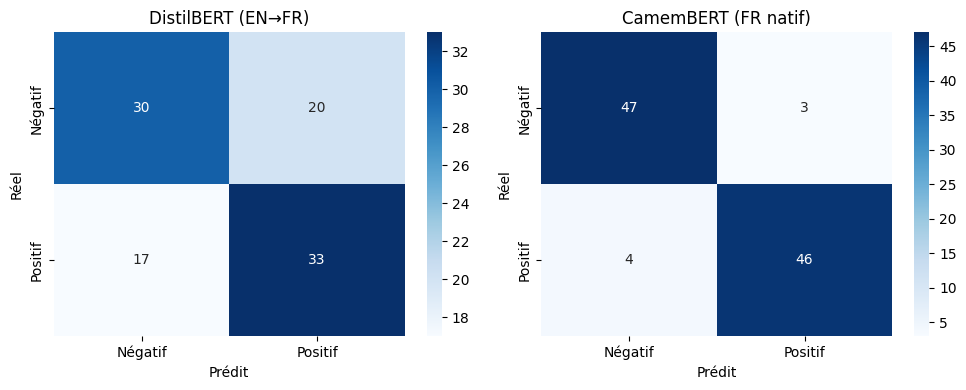

✅ Sauvegardé dans ../figures/confusion_matrices.png


In [12]:
# ╔══════════════════════════════════════════════════════╗
# CELLULE C — Classification Report + Matrices de confusion
# ╚══════════════════════════════════════════════════════╝
def get_predictions(trainer, dataset):
    preds  = trainer.predict(dataset)
    y_pred = np.argmax(preds.predictions, axis=-1)
    y_true = preds.label_ids
    return y_true, y_pred

y_true_db, y_pred_db = get_predictions(trainer_db, test_db)
y_true_cb, y_pred_cb = get_predictions(trainer_cb, test_cb)

print("=== Rapport de classification · DistilBERT ===")
print(classification_report(y_true_db, y_pred_db, target_names=["Négatif", "Positif"]))

print("=== Rapport de classification · CamemBERT ===")
print(classification_report(y_true_cb, y_pred_cb, target_names=["Négatif", "Positif"]))

# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_true, y_pred, title in zip(
    axes,
    [y_true_db, y_true_cb],
    [y_pred_db, y_pred_cb],
    ["DistilBERT (EN→FR)", "CamemBERT (FR natif)"]
):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=["Négatif", "Positif"],
                yticklabels=["Négatif", "Positif"])
    ax.set_title(title)
    ax.set_ylabel("Réel")
    ax.set_xlabel("Prédit")

plt.tight_layout()
plt.savefig('../figures/confusion_matrices.png')
plt.show()
print("✅ Sauvegardé dans ../figures/confusion_matrices.png")

In [30]:
# ╔══════════════════════════════════════════════════════╗
# CELLULE D — Conclusion finale complète P03
# ╚══════════════════════════════════════════════════════╝
best_f1_db  = df_db['f1'].max()
best_f1_cb  = df_cb['f1'].max()
delta_f1    = best_f1_cb - best_f1_db
delta_test  = metrics_cb['eval_f1'] - metrics_db['eval_f1']

print("=" * 50)
print("RÉSUMÉ FINAL — PROBLÉMATIQUE P03")
print("=" * 50)
print(f"\n{'':25} {'DistilBERT':>10} {'CamemBERT':>10}")
print("-" * 50)
print(f"{'Meilleur F1 (validation)':25} {best_f1_db:>10.4f} {best_f1_cb:>10.4f}")
print(f"{'F1 (test)':25} {metrics_db['eval_f1']:>10.4f} {metrics_cb['eval_f1']:>10.4f}")
print(f"{'Accuracy (test)':25} {metrics_db['eval_accuracy']:>10.4f} {metrics_cb['eval_accuracy']:>10.4f}")
print(f"{'Trials effectués':25} {len(df_db):>10} {len(df_cb):>10}")
print(f"{'Temps moyen / trial':25} {df_db['time_min'].mean():>9.1f}m {df_cb['time_min'].mean():>9.1f}m")
print("=" * 50)
print(f"\nΔ F1 validation : {delta_f1:+.4f}")
print(f"Δ F1 test       : {delta_test:+.4f}")
print()
if delta_test > 0:
    print(f"→ CamemBERT surpasse DistilBERT de {delta_test:.4f} en F1 sur le test")
    print("→ L'alignement linguistique natif (FR) est confirmé sur données non vues")
else:
    print(f"→ DistilBERT résiste mieux que prévu sur le test (+{-delta_test:.4f})")
    print("→ Le transfert cross-lingue est compétitif malgré la barrière linguistique")

RÉSUMÉ FINAL — PROBLÉMATIQUE P03

                          DistilBERT  CamemBERT
--------------------------------------------------
Meilleur F1 (validation)      0.6565     0.8889
F1 (test)                     0.6316     0.7619
Accuracy (test)               0.5800     0.8000
Trials effectués                   5          5
Temps moyen / trial             0.0m       0.0m

Δ F1 validation : +0.2324
Δ F1 test       : +0.1303

→ CamemBERT surpasse DistilBERT de 0.1303 en F1 sur le test
→ L'alignement linguistique natif (FR) est confirmé sur données non vues
